First 5 rows:
   total_bill   tip     sex smoker  day    time  size  price_per_person  \
0       16.99  1.01  Female     No  Sun  Dinner     2              8.49   
1       10.34  1.66    Male     No  Sun  Dinner     3              3.45   
2       21.01  3.50    Male     No  Sun  Dinner     3              7.00   
3       23.68  3.31    Male     No  Sun  Dinner     2             11.84   
4       24.59  3.61  Female     No  Sun  Dinner     4              6.15   

           Payer Name         CC Number Payment ID  
0  Christy Cunningham  3560325168603410    Sun2959  
1      Douglas Tucker  4478071379779230    Sun4608  
2      Travis Walters  6011812112971322    Sun4458  
3    Nathaniel Harris  4676137647685994    Sun5260  
4        Tonya Carter  4832732618637221    Sun2251  


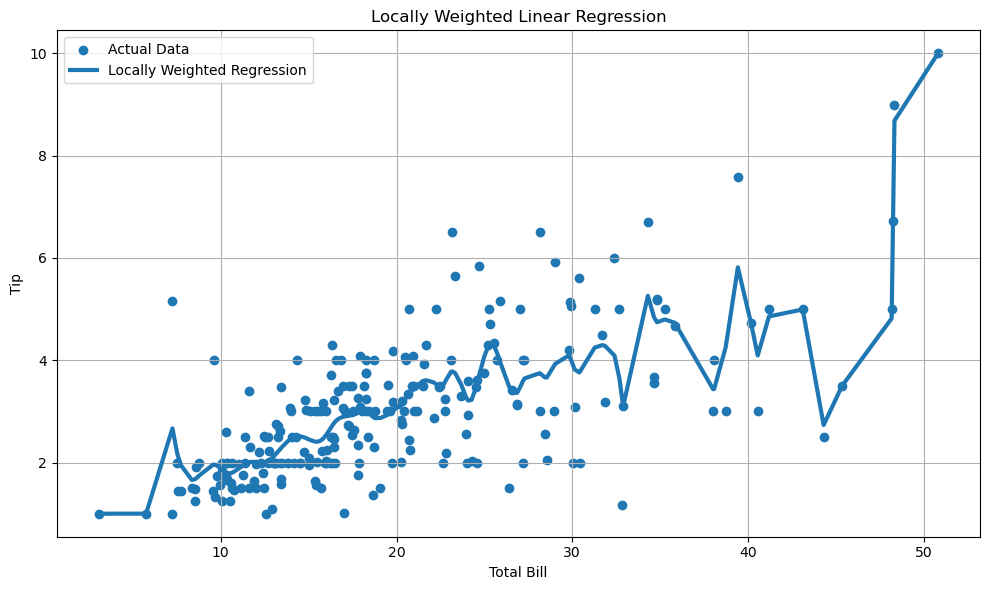

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("tips.csv")

print("First 5 rows:")
print(data.head())


bill = np.array(data["total_bill"])
tip = np.array(data["tip"])

def kernel(point, xmat, k):
    m, n = np.shape(xmat)

    weights = np.eye(m)

    for j in range(m):
        diff = point - xmat[j]

        weights[j, j] = np.exp(
            np.dot(diff, diff.T) / (-2.0 * k**2)
        )

    return weights
def localWeight(point, xmat, ymat, k):

    wei = kernel(point, xmat, k)

    W = np.linalg.inv(
        xmat.T @ (wei @ xmat)
    ) @ (
        xmat.T @ (wei @ ymat)
    )

    return W
def localWeightRegression(xmat, ymat, k):

    m, n = np.shape(xmat)

    ypred = np.zeros(m)

    for i in range(m):

        ypred[i] = (
            xmat[i] @ localWeight(
                xmat[i],
                xmat,
                ymat,
                k
            )
        )

    return ypred

mbill = np.array(bill)
mtip = np.array(tip)

m = len(mbill)

X = np.column_stack((np.ones(m), mbill))

Y = mtip

ypred = localWeightRegression(
    X,
    Y,
    0.5
)

sort_index = X[:, 1].argsort()

xsort = X[sort_index]

ypred_sort = ypred[sort_index]

plt.figure(figsize=(10, 6))

plt.scatter(
    bill,
    tip,
    label="Actual Data"
)

plt.plot(
    xsort[:, 1],
    ypred_sort,
    linewidth=3,
    label="Locally Weighted Regression"
)

plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.title("Locally Weighted Linear Regression")

plt.legend()

plt.grid(True)

plt.tight_layout()


plt.savefig("exercise6.png")

plt.show()